In [25]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [27]:
# 1. Load the Scaled Data
# Ensure 'scaled_smart_water_distribution_data.csv' is in the same folder as your notebook
print("Loading data...")
df = pd.read_csv('../data/scaled_smart_water_distribution_data.csv')

Loading data...


In [28]:
df.head()

,Timestamp,Hour_of_Day,Day_of_Week,Month,Temperature_C,Rainfall_mm,Current_Demand,Lag_1_Demand,Lag_24_Demand
0,2025-01-02 00:00:00,0.000000,0.5,0.0,0.129584,0.0,0.227788,0.325316,0.238158
1,2025-01-02 01:00:00,0.043478,0.5,0.0,0.083130,0.0,0.124081,0.227788,0.147249
2,2025-01-02 02:00:00,0.086957,0.5,0.0,0.149144,0.0,0.093042,0.124081,0.229112
3,2025-01-02 03:00:00,0.130435,0.5,0.0,0.276284,0.0,0.144234,0.093042,0.152030
4,2025-01-02 04:00:00,0.173913,0.5,0.0,0.188264,0.0,0.220800,0.144234,0.229479


In [29]:
# 2. Separate Features (Inputs) and Target (Output)
# Drop BOTH the target and the raw Timestamp string from X
X = df.drop(columns=['Current_Demand', 'Timestamp'])
y = df['Current_Demand']

In [30]:
# 3. Train/Test Split (80% for learning, 20% for testing)
# shuffle=False is CRITICAL for time-series data so we don't mix up the timeline
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print(f"Training on {len(X_train)} rows, Testing on {len(X_test)} rows.")

Training on 6988 rows, Testing on 1748 rows.


In [31]:
# 4. Initialize the Individual Models
# Model A: The Artificial Neural Network (Your core role)
# hidden_layer_sizes=(64, 32) means 2 hidden layers, fast enough for a local PC
ann_model = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=500, random_state=42)

In [32]:
# Model B: The Decision Tree Ensemble (To catch hard rules like weekends)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [33]:
# 5. Build the Hybrid Combiner
print("Building the Hybrid Voting Regressor...")
hybrid_model = VotingRegressor(estimators=[
    ('ann', ann_model),
    ('rf', rf_model)
])

Building the Hybrid Voting Regressor...


In [34]:
# 6. TRAIN THE MODEL 
print("Training the model... Please wait.")
hybrid_model.fit(X_train, y_train)

Training the model... Please wait.


,estimators,"[('ann', ...), ('rf', ...)]"
,weights,None
,n_jobs,None
,verbose,False
,loss,'squared_error'
,hidden_layer_sizes,"(64, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'


In [37]:
# 7. Make Predictions on the hidden Test Data
print("Generating predictions...")
y_pred = hybrid_model.predict(X_test)

Generating predictions...


In [38]:
# 8. Evaluate the Accuracy
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [39]:
print("\n=== MODEL PERFORMANCE METRICS ===")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-Squared (R2 Score): {r2:.4f}")


=== MODEL PERFORMANCE METRICS ===
Mean Absolute Error (MAE): 0.0382
Root Mean Squared Error (RMSE): 0.0481
R-Squared (R2 Score): 0.9250


In [40]:
# 9. Save the Final Model for the Backend Engineer
joblib.dump(hybrid_model, 'hybrid_water_model.pkl')
print("\n✅ Model successfully saved as 'hybrid_water_model.pkl'")


✅ Model successfully saved as 'hybrid_water_model.pkl'


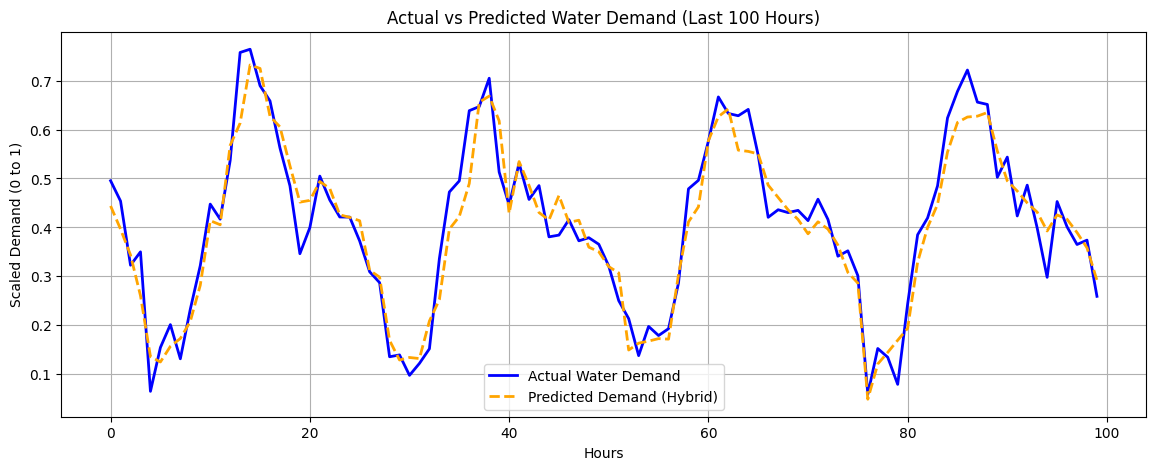

In [43]:
# 10. Visualize the Results
plt.figure(figsize=(14, 5))
plt.plot(y_test.values[-100:], label='Actual Water Demand', color='blue', linewidth=2)
plt.plot(y_pred[-100:], label='Predicted Demand (Hybrid)', color='orange', linestyle='dashed', linewidth=2)
plt.title('Actual vs Predicted Water Demand (Last 100 Hours)')
plt.xlabel('Hours')
plt.ylabel('Scaled Demand (0 to 1)')
plt.legend()
plt.grid(True)
plt.show()

In [44]:
print("Training Standalone MLP...")
ann_model.fit(X_train, y_train)

print("Training Hybrid Ensemble...")
#already done in the step 6

Training Standalone MLP...
Training Hybrid Ensemble...


In [ ]:
mlp_preds = ann_model.predict(X_test)
#the step 7 predicts hybrid model

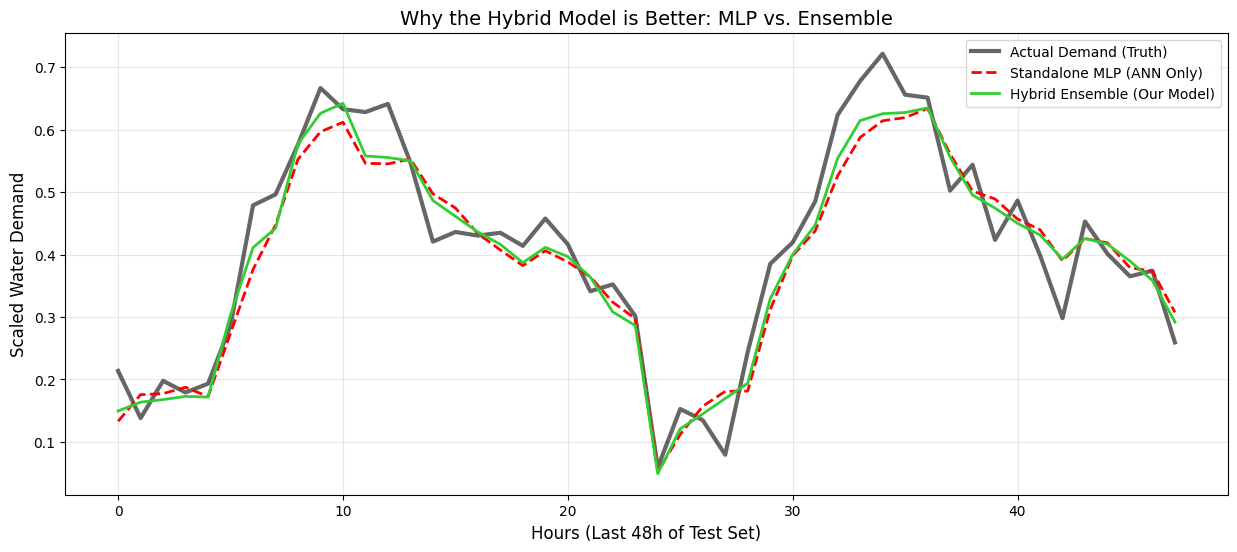

In [47]:
import matplotlib.pyplot as plt

# We will zoom in on the last 48 hours to see the detail
window = 48
plt.figure(figsize=(15, 6))

# 1. Plot the Ground Truth
plt.plot(y_test.values[-window:], label='Actual Demand (Truth)', color='black', linewidth=3, alpha=0.6)

# 2. Plot the MLP (ANN Only)
plt.plot(mlp_preds[-window:], label='Standalone MLP (ANN Only)', color='red', linestyle='--', linewidth=2)

# 3. Plot the Hybrid (ANN + RF)
plt.plot(y_pred[-window:], label='Hybrid Ensemble (Our Model)', color='limegreen', linewidth=2)

plt.title('Why the Hybrid Model is Better: MLP vs. Ensemble', fontsize=14)
plt.xlabel('Hours (Last 48h of Test Set)', fontsize=12)
plt.ylabel('Scaled Water Demand', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

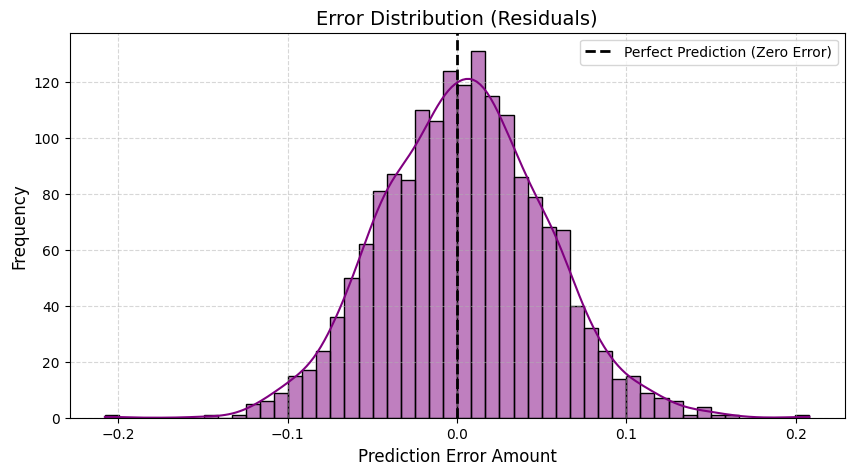

In [48]:
import seaborn as sns

# Calculate the errors (Residuals) for the Hybrid model
residuals = y_test - y_pred

plt.figure(figsize=(10, 5))
# Use seaborn to make a beautiful histogram with a curve
sns.histplot(residuals, bins=50, kde=True, color='purple')

plt.title('Error Distribution (Residuals)', fontsize=14)
plt.xlabel('Prediction Error Amount', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Perfect Prediction (Zero Error)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

--- Accuracy Comparison Report ---
Standalone MLP Error (MAE): 0.0444
Hybrid Ensemble Error (MAE): 0.0382
✨ Total Accuracy Improvement: 14.14%


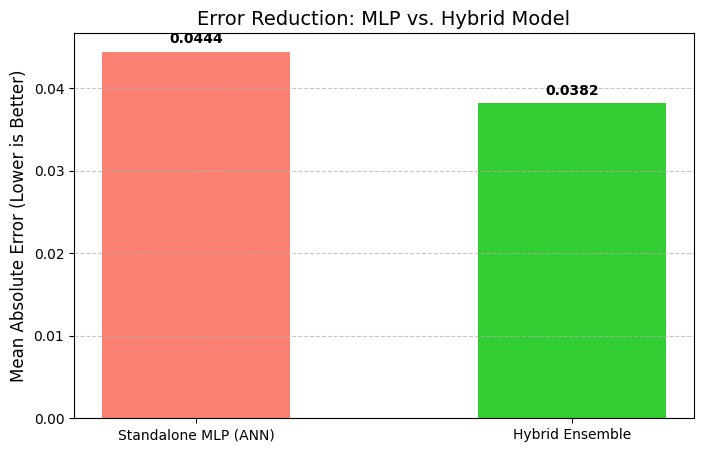

In [49]:
# 1. Calculate MAE for both versions
from sklearn.metrics import mean_absolute_error

mae_mlp = mean_absolute_error(y_test, mlp_preds)
mae_hybrid = mean_absolute_error(y_test, y_pred)

# 2. Calculate the Percentage Improvement
# Formula: ((Old Error - New Error) / Old Error) * 100
improvement = ((mae_mlp - mae_hybrid) / mae_mlp) * 100

print("--- Accuracy Comparison Report ---")
print(f"Standalone MLP Error (MAE): {mae_mlp:.4f}")
print(f"Hybrid Ensemble Error (MAE): {mae_hybrid:.4f}")
print(f"✨ Total Accuracy Improvement: {improvement:.2f}%")

# 3. Create a Bar Chart for the Presentation Slide
plt.figure(figsize=(8, 5))
models = ['Standalone MLP (ANN)', 'Hybrid Ensemble']
errors = [mae_mlp, mae_hybrid]

plt.bar(models, errors, color=['salmon', 'limegreen'], width=0.5)
plt.title('Error Reduction: MLP vs. Hybrid Model', fontsize=14)
plt.ylabel('Mean Absolute Error (Lower is Better)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add the numbers on top of the bars
for i, v in enumerate(errors):
    plt.text(i, v + 0.001, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()

c:\Users\Acer\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


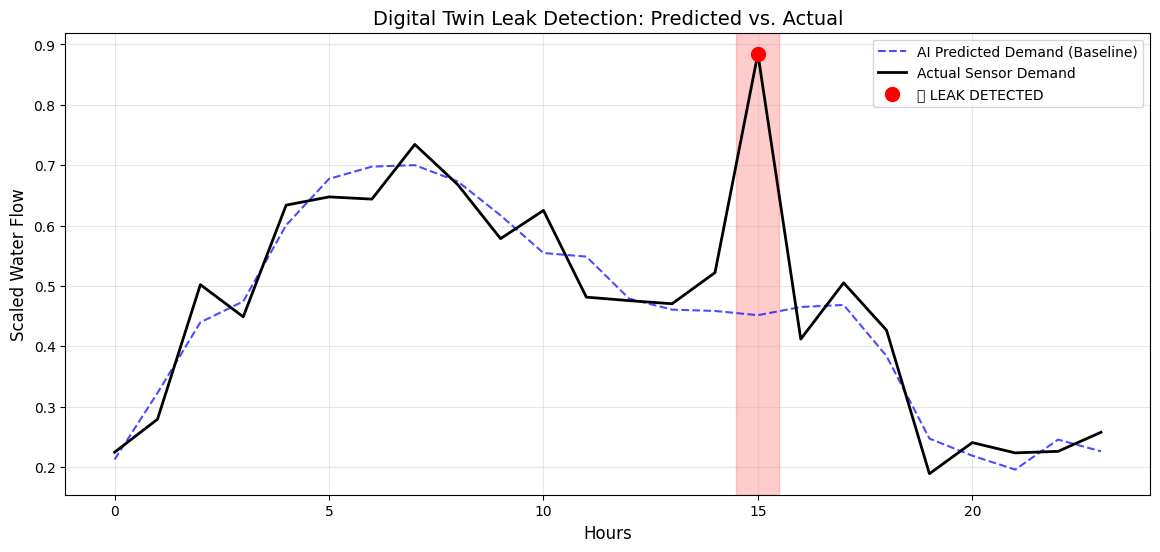

Status at Hour 15: LEAK ALERT!


In [50]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Take a small sample of actual data (e.g., 24 hours)
sample_actual = y_test.values[:24].copy()
sample_pred = y_pred[:24].copy()

# 2. SIMULATE A LEAK: Manually spike the actual data at Hour 15
# We add 0.4 (scaled) to represent a massive pipe burst
sample_actual[15] += 0.4 

# 3. Calculate the Residual (Difference)
threshold = 0.15 # Our defined safety margin
residuals = np.abs(sample_actual - sample_pred)
leaks = residuals > threshold

# 4. PLOT THE RESULTS
plt.figure(figsize=(14, 6))

# Plot the AI's "Expected" Baseline
plt.plot(sample_pred, label='AI Predicted Demand (Baseline)', color='blue', linestyle='--', alpha=0.7)

# Plot the "Sensor" Data (with the simulated leak)
plt.plot(sample_actual, label='Actual Sensor Demand', color='black', linewidth=2)

# Highlight the Leak Point in Red
plt.scatter(15, sample_actual[15], color='red', s=100, label='🚨 LEAK DETECTED', zorder=5)
plt.axvspan(14.5, 15.5, color='red', alpha=0.2) # Red highlight box

plt.title('Digital Twin Leak Detection: Predicted vs. Actual', fontsize=14)
plt.xlabel('Hours', fontsize=12)
plt.ylabel('Scaled Water Flow', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Status at Hour 15: { 'LEAK ALERT!' if leaks[15] else 'Normal' }")

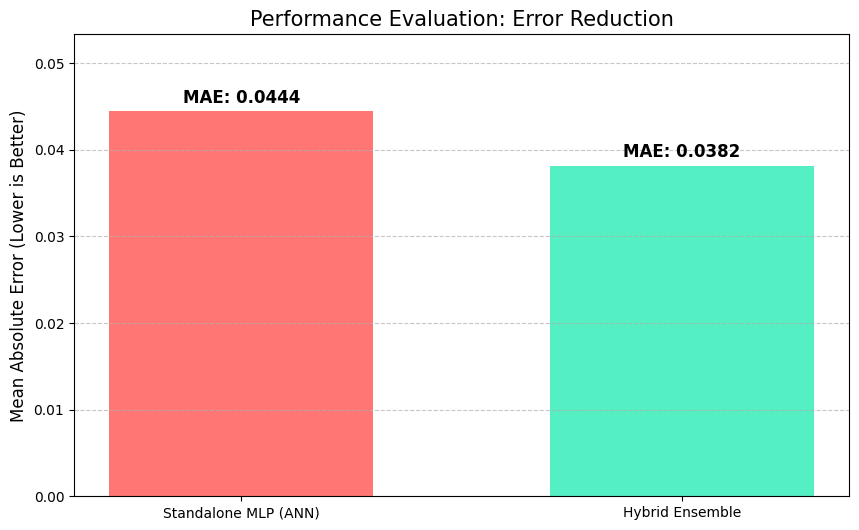

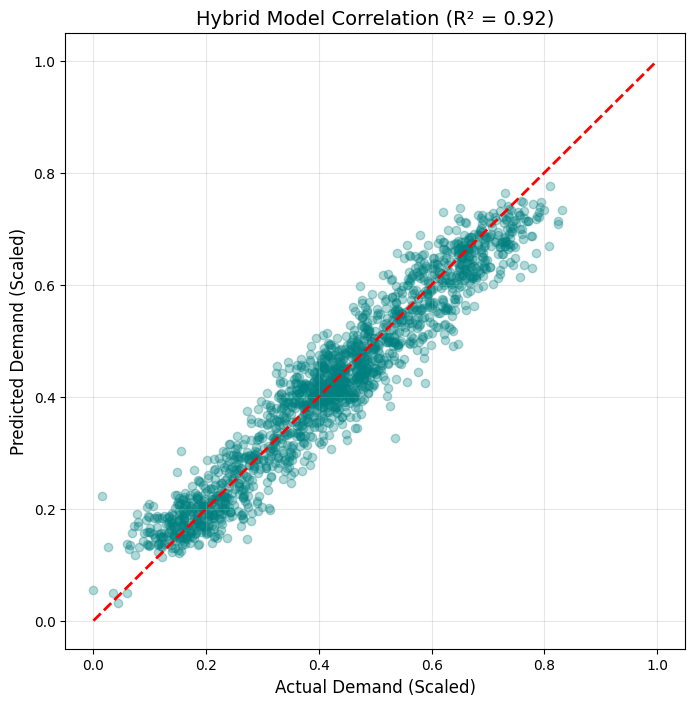

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Accuracy Comparison Bar Chart (MAE)
plt.figure(figsize=(10, 6))
model_names = ['Standalone MLP (ANN)', 'Hybrid Ensemble']
mae_values = [mae_mlp, mae_hybrid] # From our previous calculation

colors = ['#ff7675', '#55efc4']
plt.bar(model_names, mae_values, color=colors, width=0.6)

# Adding the values on top
for i, v in enumerate(mae_values):
    plt.text(i, v + 0.001, f"MAE: {v:.4f}", ha='center', fontweight='bold', fontsize=12)

plt.title('Performance Evaluation: Error Reduction', fontsize=15)
plt.ylabel('Mean Absolute Error (Lower is Better)', fontsize=12)
plt.ylim(0, max(mae_values) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Scatter Plot: Predicted vs. Actual (The "Correlation" Test)
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.3, color='teal')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2) # Perfect 1:1 line

plt.title(f'Hybrid Model Correlation (R² = {r2:.2f})', fontsize=14)
plt.xlabel('Actual Demand (Scaled)', fontsize=12)
plt.ylabel('Predicted Demand (Scaled)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()